# Preliminaries

In [2]:
import numpy as np
import numpy.polynomial.polynomial as poly

import matplotlib.pyplot as plt
from matplotlib import cm, ticker
from matplotlib.ticker import FormatStrFormatter

import scipy.constants as const
from scipy.signal import fftconvolve, welch
from scipy import optimize

import pycbc.psd, pycbc.filter, pycbc.noise
from pycbc.types import TimeSeries

plt.rcParams['text.usetex'] = True

#define the solar mass in [kg] and parsec in [meters]
sol = 1.989e30
pc = 3.086e16

/opt/anaconda3/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [3]:
#for the waveforms of the quasi-circular binary system and quasi-circular Lagrange triple
import waveforms

print(waveforms.CircularBinary.__doc__)
print(waveforms.CircularLagrangeTriple.__doc__)

CircularBinary contains the waveforms for a quasi-circular binary system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence [rad]
    

    CircularLagrangeTriple contains the waveforms for a quasi-circular Lagrange three-body system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2, m3 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence

# 1: Chirp Mass and Stability of the Lagrange Triple

The expression for the chirp mass of the Lagrange triple is

$$
M_{(\mathrm{3B})} = \mathcal{M}_{(\mathrm{3B})} \Bigl[ \frac{\beta_1\beta_2 + \beta_1\beta_3 + \beta_2\beta_3}{(\beta_1\beta_2 + \beta_2\beta_3 + \beta_1\beta_3)^2 - 3(\beta_1^2\beta_2\beta_3 + \beta_1\beta_2^2\beta_3 + \beta_1\beta_2\beta_3^2)} \Bigr]^{3/5}
$$

This is equivalent to the definition of Asada (2009). Using $\beta_3 = 1 - \beta_1 - \beta_2$, we can plot the total mass $M_{(\mathrm{3B})}$ as a function of the mass ratios $\beta_1$ and $\beta_2$, assuming we know the chirp mass of the Lagrange triple.

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/2937776525.py:2: RuntimeWarning: divide by zero encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/2937776525.py:2: RuntimeWarning: invalid value encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/2937776525.py:2: RuntimeWarning: invalid value encountered in power
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)


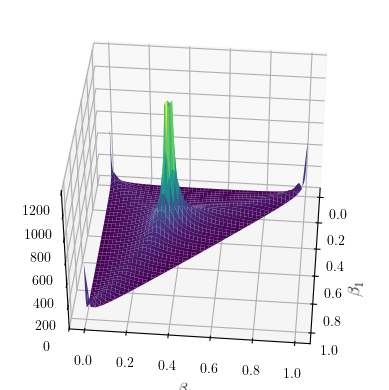

In [6]:
def M_chirp_betas(b1, b2, b3):
    return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)

fig = plt.figure()
ax = fig.add_subplot(projection = "3d")
b1 = np.linspace(0, 1, 1000)
b2 = np.linspace(0, 1, 1000)
b1_grid, b2_grid = np.meshgrid(b1, b2)

M_c_betas = M_chirp_betas(b1_grid, b2_grid, 1 - b1_grid - b2_grid)
M_c_betas[b1_grid + b2_grid > 1] = np.nan
M_c_betas[M_c_betas > 150] = np.nan

surf = ax.plot_surface(b1_grid, b2_grid, 8*M_c_betas, linewidth = 0, cmap=cm.viridis, antialiased = True)

ax.set_xlabel(r"$\beta_1$", fontsize = "large")
ax.set_ylabel(r"$\beta_2$", fontsize = "large")
#ax.set_zlabel(r"$M_{(\mathrm{3B})}$", fontsize = "large", rotation = 90)

#ax.set_zlim(0, 150)
ax.zaxis.labelpad = -1

ax.grid()
ax.view_init(40, 5)
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/1845057184.py:2: RuntimeWarning: divide by zero encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/1845057184.py:2: RuntimeWarning: invalid value encountered in divide
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/1845057184.py:2: RuntimeWarning: invalid value encountered in power
  return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)


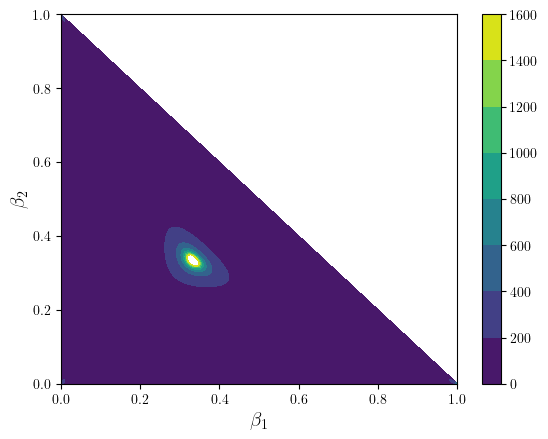

In [7]:
def M_chirp_betas(b1, b2, b3):
    return (0.5 * ((b1**2)*(b2 - b3)**2 + (b2**2)*(b3 - b1)**2 + (b3**2)*(b1 - b2)**2)/(b1*b2 + b1*b3 + b2*b3))**(-3/5)

fig, ax = plt.subplots()
b1 = np.linspace(0, 1, 1000)
b2 = np.linspace(0, 1, 1000)
b1_grid, b2_grid = np.meshgrid(b1, b2)

M_c_betas = M_chirp_betas(b1_grid, b2_grid, 1 - b1_grid - b2_grid)
M_c_betas[b1_grid + b2_grid > 1] = np.nan
M_c_betas[M_c_betas > 200] = np.nan

countour_totalMass = ax.contourf(b1_grid, b2_grid, 8*M_c_betas, cmap=cm.viridis)

ax.set_xlabel(r"$\beta_1$", fontsize = "x-large")
ax.set_ylabel(r"$\beta_2$", fontsize = "x-large")
cbar = fig.colorbar(countour_totalMass)

plt.show()

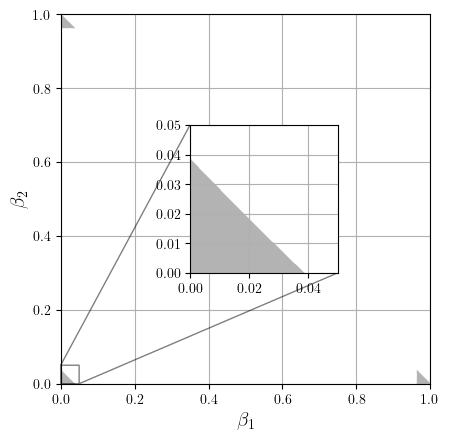

In [8]:
b1 = np.linspace(0, 1, 5000)
b2 = np.linspace(0, 1, 5000)
b1_grid, b2_grid = np.meshgrid(b1, b2)

stability = b1_grid*b2_grid + (b1_grid + b2_grid)*(1 - b1_grid - b2_grid) < 1/27
physicalMassRatios = b1_grid + b2_grid <= 1

fig, ax = plt.subplots()

#plot the stability region
ax.imshow( (stability & physicalMassRatios).astype(float), 
            extent=(b1_grid.min(), b1_grid.max(), b2_grid.min(), b2_grid.max()), 
            origin = "lower", cmap = "Greys", alpha=0.3)

ax.set_xlabel(r"$\beta_1$", fontsize = "x-large")
ax.set_ylabel(r"$\beta_2$", fontsize = "x-large")
ax.grid(True)

#inset plot
axins = ax.inset_axes([0.3, 0.3, 0.5, 0.4], xlim = (0, 0.05), ylim = (0, 0.05))
axins.imshow( (stability & physicalMassRatios).astype(float), 
            extent=(b1_grid.min(), b1_grid.max(), b2_grid.min(), b2_grid.max()), 
            origin = "lower", cmap = "Greys", alpha=0.3)
axins.grid(True)
ax.indicate_inset_zoom(axins, edgecolor = "black")

plt.savefig("LaTeX Files/Figures/System Configuration/Stability of the Lagrange Triple.pdf", bbox_inches = "tight")
plt.show()

# 2: Waveform Degeneracy up to the Mass Quadrupole

In [10]:
params_2B = [150e-13, 10, 8, 2e6, 30, 0]
binary = waveforms.CircularBinary(*params_2B)

print("Binary chirp mass in solar mass = {}".format(binary.M_c/sol))

Binary chirp mass in solar mass = 7.776774233174123


In [11]:
params_2B_asymm = [150e-13, 30, 2, 2e6, 15, 0]
binary_asymm = waveforms.CircularBinary(*params_2B_asymm)

print("Binary chirp mass in solar mass = {}".format(binary_asymm.M_c/sol))

Binary chirp mass in solar mass = 5.832580674880592


## Functions for Finding Mass Quadrupole Degeneracies

In [13]:
def findQuadDegeneracy_plus(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*(1 + (np.cos(i_3B))**2))/(1 + (np.cos(i_2B))**2)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

def findQuadDegeneracy_cross(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*np.cos(i_3B))/np.cos(i_2B)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

/opt/anaconda3/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


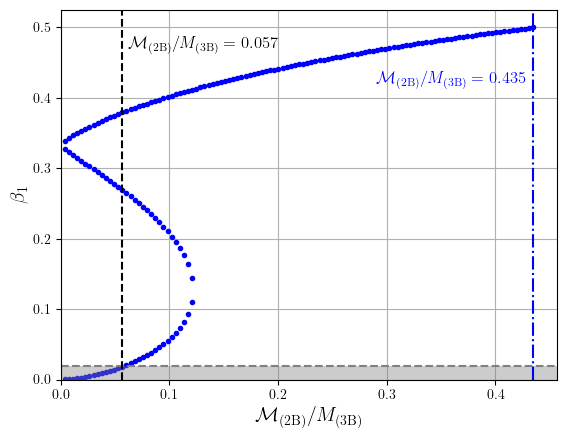

In [14]:
a1 = np.linspace(0, 0.45, 120)

#plt.figure(figsize = (10,5))

checkLastStableValue = 0
checkAllowedValues = []

for val in a1:
    temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    temp = temp[np.isclose(temp.imag, 0)]
    temp = temp[temp > 0]

    for root in temp:
        if root <= 0.5:
            plt.scatter(val, root, color = "blue", marker = ".")

            if val not in checkAllowedValues:
                checkAllowedValues.append(val)
    
    if len(temp) > 0 and np.min(temp) < np.min(np.roots([-3, 2, -1/27])):
        checkLastStableValue = val

plt.xlabel(r"$\mathcal{M}_{\mathrm{(2B)}}/M_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.ylabel(r"$\beta_1$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.ylim(0)
plt.xlim(0)

#plot stability regions
plt.axhspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axhline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")
plt.axvline(checkAllowedValues[-1], color = "blue", ls = "-.")
plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}}/M_{{\mathrm{{(3B)}}}} = {:.3f}$".format(checkAllowedValues[-1]),
             xy = (checkAllowedValues[-1] - 0.145, 0.42), fontsize = 12, color = "blue")
plt.axvline(checkLastStableValue, color = "black", ls = "--")
plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}}/M_{{\mathrm{{(3B)}}}} = {:.3f}$".format(checkLastStableValue),
             xy = (checkLastStableValue + 0.005, 0.47), fontsize = 12)

plt.savefig("LaTeX Files/Figures/Chirp Mass/Roots of G(beta_1).pdf", bbox_inches = "tight")
plt.show()

## Mass Quadrupole Degeneracy Surface

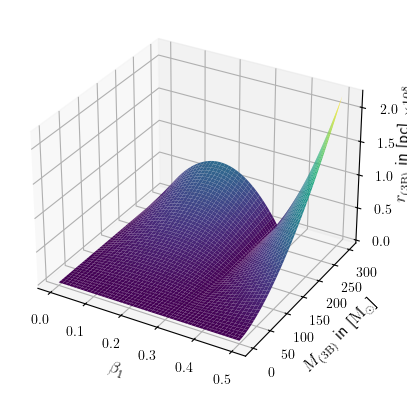

In [16]:
#assuming a binary at a distance 2e6 pc from the observer
def r_3B_MQFullDegeneracy(beta_1, M_3B, r_2B = 2e6*pc):
    #units will be in m
    return ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1))

fig = plt.figure()
ax = fig.add_subplot(projection = "3d")
b1 = np.linspace(0, 0.5, 1000)
M_3B = np.linspace(0, 300, 1000)*sol
b1_grid, M_3B_grid = np.meshgrid(b1, M_3B)

r_3B_surface = r_3B_MQFullDegeneracy(b1_grid, M_3B_grid)

surf = ax.plot_surface(b1_grid, M_3B_grid/sol, r_3B_surface/pc, linewidth = 0, cmap = cm.viridis, antialiased = True)

ax.set_xlabel(r"$\beta_1$", fontsize = "large")
ax.set_ylabel(r"$M_{\mathrm{(3B)}}$ in [$\mathrm{M}_{\odot}$]", fontsize = "large")
ax.set_zlabel(r"$r_{\mathrm{(3B)}}$ in [pc]", fontsize = "large", rotation = 90)

#ax.set_zlim(0, 150)
ax.zaxis.labelpad = -1

ax.grid()
#ax.view_init(30, 120)
plt.show()

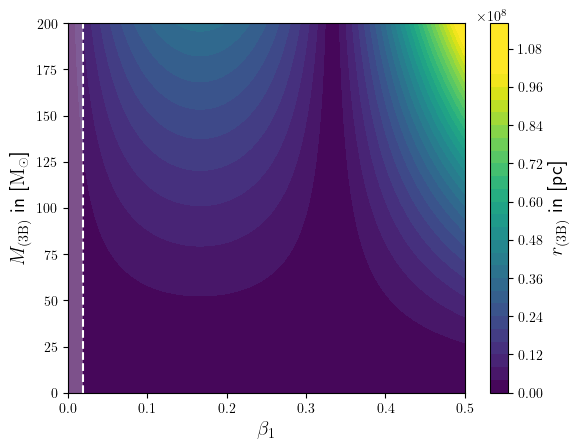

In [98]:
fig, ax = plt.subplots()

b1 = np.linspace(0, 0.5, 1000)
M_3B = np.linspace(0, 200, 1000)*sol
b1_grid, M_3B_grid = np.meshgrid(b1, M_3B)

r_3B_surface = r_3B_MQFullDegeneracy(b1_grid, M_3B_grid)
r_3B_countour = ax.contourf(b1_grid, M_3B_grid/sol, r_3B_surface/pc, cmap = cm.viridis, levels = 30,
                            vmin = 1e5, vmax = 1e8)

#plot the stability region
ax.axvspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "white", alpha = 0.3)
ax.axvline(np.min(np.roots([-3, 2, -1/27])), color = "white", ls = "--")

ax.set_xlabel(r"$\beta_1$", fontsize = "x-large")
ax.set_ylabel(r"$M_{\mathrm{(3B)}}$ in [$\mathrm{M}_{\odot}$]", fontsize = "x-large")
cbar = fig.colorbar(r_3B_countour)
cbar.set_label(r"$r_{\mathrm{(3B)}}$ in [pc]", fontsize = "x-large")

plt.savefig("LaTeX Files/Figures/Quadrupole Degeneracy/Contour plot of r_3B.pdf", bbox_inches = "tight")
plt.show()

## Case 1: Mass Quadrupole Degeneracy at Short Time Scales

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:195: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:199: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.25, m2 = 2.25, m3 = 145.5, r = 3974454.8960382254, i = 30, phi = 4.824027157764506

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6640397499996263



(np.float64(0.8384901547585671), np.float64(15.770620283691056))

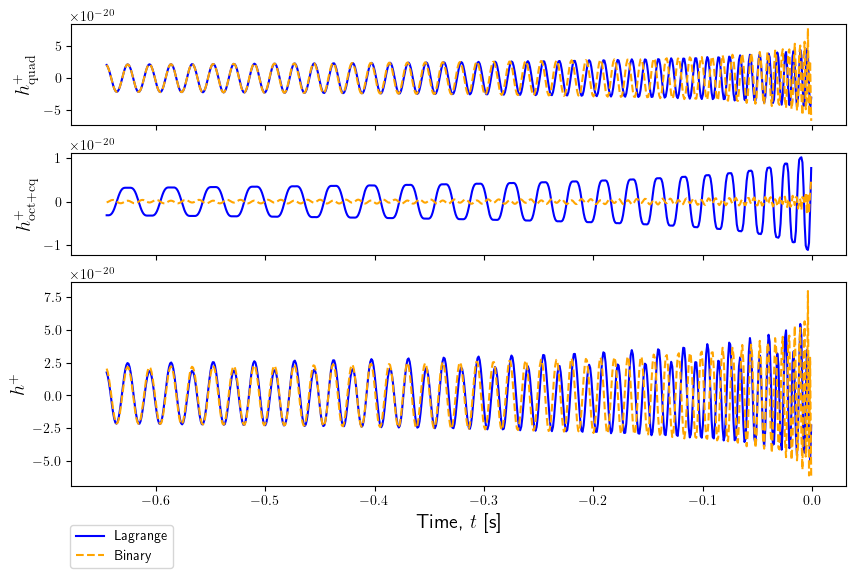

In [19]:
delta_t = 1/1000
t_max = 0.645

beta_1 = 0.015
M_3B = 150
i_3B = 30
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad1 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad1, t_max = t_max, delta_t = delta_t, radRxn = True,
                             size = "horizontal", 
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/MQ Plus Degeneracy 1 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.25, m2 = 2.25, m3 = 145.5, r = 3974454.896038225, i = 30, phi = 4.824027157764506

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6640397499996263



(np.float64(nan), np.float64(nan))

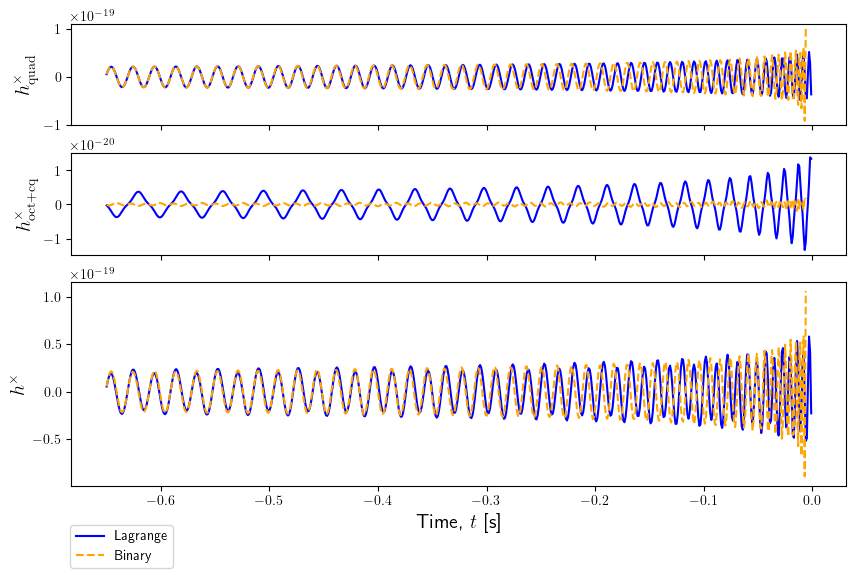

In [20]:
delta_t = 1/1000
t_max = 0.65

beta_1 = 0.015
M_3B = 150
i_3B = 30
quad_result = findQuadDegeneracy_cross(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad1 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross", size = "horizontal", 
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/MQ Cross Degeneracy 1 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

## Case 2: Mass Quadrupole Degeneracy up to the Coalescence Time

Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.3231939027306483, m2 = 2.3231939027306483, m3 = 145.3536121945387, r = 4525962.497957064, i = 15, phi = 6.283185307179586

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6446118194246188



(np.float64(nan), np.float64(nan))

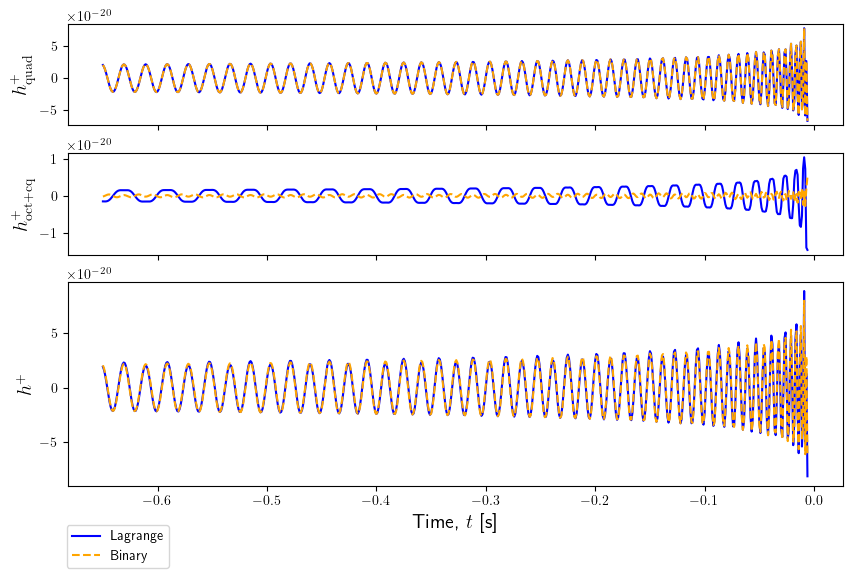

In [22]:
delta_t = 1/1000
t_max = 0.65

M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
i_3B = 15
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad4 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad4, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad4, t_max = t_max, delta_t = delta_t, radRxn = True, size = "horizontal",
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/MQ Plus Degeneracy 2 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad4).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.3231939027306483, m2 = 2.3231939027306483, m3 = 145.3536121945387, r = 4570118.260058655, i = 15, phi = 6.283185307179586

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6446118194246188



(np.float64(nan), np.float64(nan))

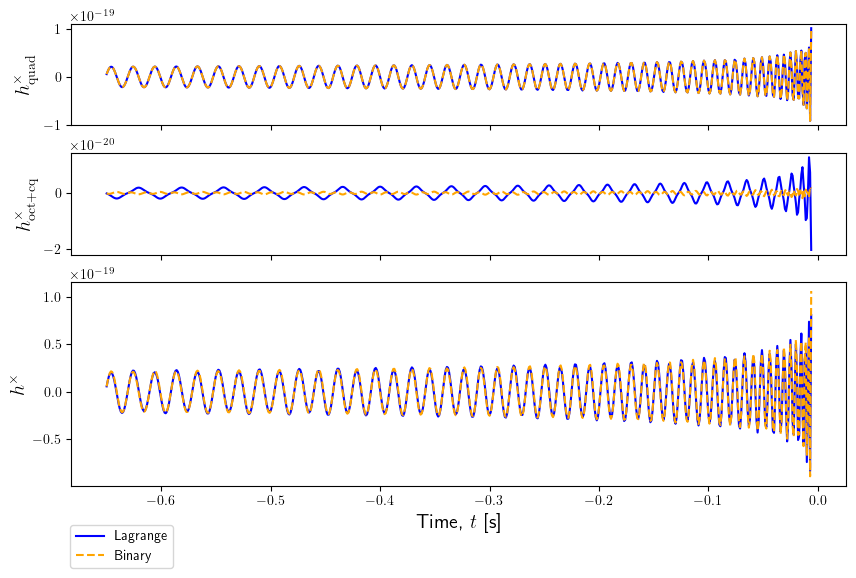

In [23]:
delta_t = 1/1000
t_max = 0.65

M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
i_3B = 15
quad_result = findQuadDegeneracy_cross(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad4 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad4, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad4, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross", size = "horizontal",
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/MQ Cross Degeneracy 2 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad4).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hc_2B, hc_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

# 3: Waveform Degeneracy up to the 0.5PN

## Functions for Finding 0.5PN Degeneracies

In [26]:
def F(b1, b2):
    num = 3*((b1 + b2 - 1)**2)*((2*b1**2 + (b1 + b2)*(2*b2 - 1))**2) + (b1 - 3*b1**2 + 2*b1**3 + b2*(b2*(3 - 2*b2) - 1))**2
    denom = 27*(b1**2)*(b2**2)*((b1 + b2 - 1)**2) + ((b1 - b2)**2)*((2*b1 + b2 - 1)**2)*((b1 + 2*b2 - 1)**2)

    return np.sqrt(num/denom)

def iota(b1, b2, ratio_w_3w):
    return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))

def iota_arccos(b1, b2, ratio_w_3w):
    return np.degrees(np.arccos(np.sqrt( 4/((27/2)*ratio_w_3w/F(b1, b2) - 1) - 9) ))

def find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    b3 = 1 - 2*b1
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))

    term1 = (np.sqrt(3)*b3/8)*(amp_quadPlus_2B/amp_octcqPlus_2B_w)*(np.sin(i_3B)*(5 + np.cos(i_3B)**2)/(1 + np.cos(i_3B)**2))*((w_2B/const.c)**(1/3))
    term2 = (9*np.sqrt(27)/8)*(b1*b3/np.abs(b1 - b3))*(amp_quadPlus_2B/amp_octcqPlus_2B_3w)*np.sin(i_3B)*((w_2B/const.c)**(1/3))

    return ((const.c**2)/const.G) * ((1/2)*(term1**(-3)) + (1/2)*(term2**(-3)))

def find_r(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    t = np.linspace(0, 1000, 10000)
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))
    b3 = 1 - 2*b1
    M_3B = find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1)

    term1 = 2*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(b1 - b3)*(1 + np.cos(i_3B)**2)
    term2 = (np.sqrt(3)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*b3*np.abs(b1 - b3)*np.sin(i_3B)*(5 + np.cos(i_3B)**2)
    term3 = (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*b3*np.sin(i_3B)*(1 + np.cos(i_3B)**2)
    
    return (term1 + term2 + term3)/(amp_quadPlus_2B + amp_octcqPlus_2B_w + amp_octcqPlus_2B_3w)

def findOctDegeneracy_plus(params_binary, beta_1, filename = "", radRxn = False, suppressPrint = False, atol = 1e-23):
    #initialization
    binary = waveforms.CircularBinary(*params_binary)
    
    #generate the data
    ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]
    
    b1 = np.linspace(0, 1, 500000)
    b2 = np.linspace(0, 1, 500000)
    i_3B = iota(b1, b2, ratio_w_3w)
    i_3B[b1 > 0.5] = np.nan
    
    #plot M_3B and r_3B for the given binary system
    #find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
    b1_filtered = b1[np.where(~np.isnan(i_3B))]

    if suppressPrint == False:
        print("Min beta_1 for true degeneracy = {}".format(b1_filtered[0]))
        print("Max beta_1 for true degeneracy = {}".format(b1_filtered[-1]))

    if b1_filtered[0] < beta_1 < b1_filtered[-1]:
        #calculate the parameters obtainable from the given binary system      
        w_2B = np.sqrt(const.G*(params_binary[1]*sol + params_binary[2]*sol)/((params_binary[0]*pc)**3))

        #find the parameters of the equivalent Lagrange triple
        M_3B = find_M_3B(*params_binary, beta_1)
        r_3B = find_r(*params_binary, beta_1)
        b = (const.G*M_3B/(w_2B**2))**(1/3)
        m1_3B = M_3B*beta_1
        m3_3B = M_3B - 2*m1_3B
        i_3B_deg = iota(beta_1, beta_1, ratio_w_3w)

        delta_t = 1/5000
        t_max = 3
        phi_3B = 0
        shift = np.linspace(0, 2*np.pi, 1000)

        for phi in shift:
            temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
            lagrange = waveforms.CircularLagrangeTriple(*temp)
            check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4])
            
            if all(np.isclose(check, 0, atol = atol)):
                phi_3B = phi

        #compile the parameters of the triple into one list
        return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]
    else:
        print("Mass ratio not in the region for plus degeneracy.")

In [27]:
def octDegeneracy_cross_equations(init, params_binary, beta_1):
    #initial conditions must be in SI units (distances in [m], masses in [kg], angles in [rad])
    r_3B, M_3B, i_3B = init
    b1 = beta_1
    binary = waveforms.CircularBinary(*params_binary)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))

    eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(i_3B)/r_3B
    eq2 = binary.h_octcq(1, ampOnly = True, pol = "cross")[0] - (np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*(1 - 2*b1)*np.abs(3*b1 - 1)*np.sin(2*i_3B)/r_3B
    eq3 = binary.h_octcq(1, ampOnly = True, pol = "cross")[1] - (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*(1 - 2*b1)*np.sin(2*i_3B)/r_3B
    
    return [eq1, eq2, eq3]

def findOctDegeneracy_cross(init, a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, beta_1, method = "lm", root_tol = 1e-25, atol = 1e-23):
    binary = waveforms.CircularBinary(*[a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B])
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    
    #input initial conditions for root finding must be in pc and solar masses
    #r_3B in [m], M_3B in [kg], and i_3B in [rad]
    solved_params_3B = optimize.root(octDegeneracy_cross_equations, [init[0]*pc, init[1]*sol, np.radians(init[2])],
                            method = method, tol = root_tol, args = ([a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B], beta_1))
    print(solved_params_3B.message)
    r_3B, M_3B, i_3B = solved_params_3B.x
    b = (const.G*M_3B/(w_2B**2))**(1/3)
    m1_3B = M_3B*beta_1
    m3_3B = M_3B - 2*m1_3B
    i_3B_deg = np.degrees(i_3B)

    delta_t = 1/5000
    t_max = 3
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    
    for phi in shift:
        temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4])
                
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi
    
    return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]

#test case
findOctDegeneracy_cross([6655437.262202962, 55.2350117, 1.917277536430065], *params_2B, 0.15915)

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/1930833302.py:8: RuntimeWarning: invalid value encountered in scalar power
  eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(i_3B)/r_3B


Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000


[np.float64(2.1020970558551414e-11),
 np.float64(7.884309472721448),
 np.float64(7.884309472721448),
 np.float64(33.77149712569406),
 np.float64(4201544.048361028),
 np.float64(2.0845160434197947),
 np.float64(5.031579825569238)]

## 0.5PN Degeneracy Curves

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


[0.15909232 0.15909432 0.15909632 ... 0.2011444  0.2011464  0.2011484 ]


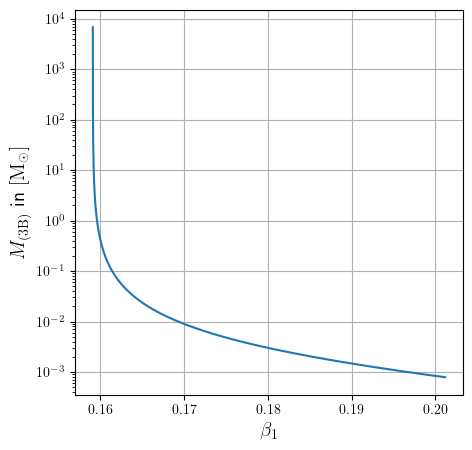

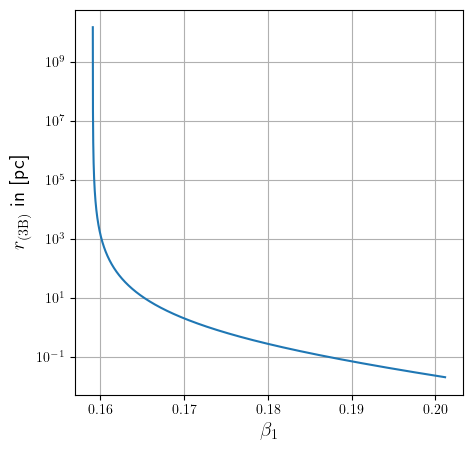

In [29]:
#generate the data
ratio_w_3w = ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]

b1 = np.linspace(0, 1, 500000)
b2 = np.linspace(0, 1, 500000)
i_3B = iota(b1, b2, ratio_w_3w)
i_3B[b1 > 0.5] = np.nan

#plot M_3B and r_3B for the given binary system
#find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
b1_filtered = b1[np.where(~np.isnan(i_3B))]
print(b1_filtered)

start_index = 0

fig = plt.figure(figsize = (5, 5))
plt.plot(b1_filtered[start_index:], find_M_3B(*params_2B, b1_filtered[start_index:])/sol)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$M_{\mathrm{(3B)}}$ in $[\mathrm{M}_{\odot}]$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/M_3B vs beta_1.pdf", bbox_inches = "tight")
plt.show()

fig = plt.figure(figsize = (5, 5))
plt.plot(b1_filtered[start_index:], find_r(*params_2B, b1_filtered[start_index:])/pc)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$r_{\mathrm{(3B)}}$ in [pc]", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/r_3B vs beta_1.pdf", bbox_inches = "tight")
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


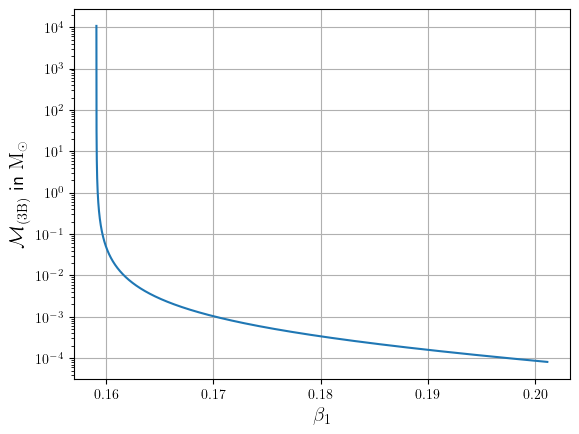

In [30]:
#generate the data
delta_t = 1/1000
t_max = 0.5
binary = waveforms.CircularBinary(*params_2B)

ratio_w_3w = binary.h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus")[1]

b1 = np.linspace(0, 1, 1000000)
i_3B = iota(b1, b1, ratio_w_3w)
i_3B[b1 > 0.5] = np.nan

#find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
b1_filtered = b1[np.where(~np.isnan(i_3B))]

plt.plot(b1_filtered, (find_M_3B(*params_2B, b1_filtered)/sol)*((b1_filtered*((1 - 3*b1_filtered)**2))/(2 - 3*b1_filtered))**(3/5))
#plt.axhline(binary.M_c/sol, color = "black", ls = "dashed")
#plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}} = {:.4f} \ \mathrm{{M}}_{{\odot}}$".format(binary.M_c/sol), xy = (0.162, 15), fontsize = 13)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$\mathcal{M}_{\mathrm{(3B)}}$ in $\mathrm{M}_{\odot}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

plt.savefig("LaTeX Files/Figures/Chirp Mass/M_chirp vs beta_1.pdf", bbox_inches = "tight")
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


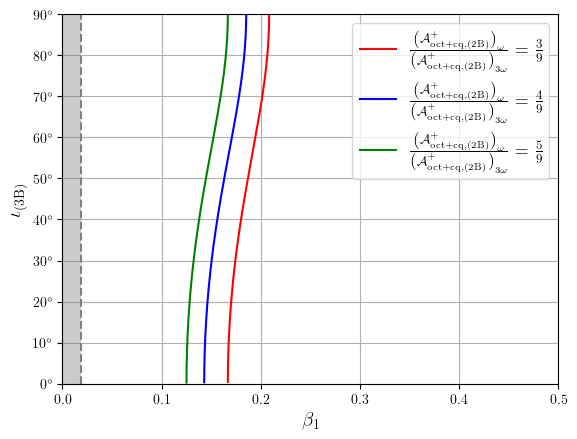

In [31]:
#generate the data
ratios = [3/9, 4/9, 5/9]
b1 = np.linspace(0, 0.5, 200000)

#colors and line styles for plotting
colors = ["Red", "Blue", "Green"]
ratio_labels = [r"$\ \frac{3}{9}$", r"$\ \frac{4}{9}$", r"$\ \frac{5}{9}$"]

for i in range(len(ratios)):
    plt.plot(b1, iota(b1, b1, ratios[i]), color = colors[i],
             label = r"$\frac{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{\omega}}{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{3\omega}} = $" + ratio_labels[i])

#plot the stability region
plt.axvspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axvline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")

plt.legend(fontsize = 13)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$\iota_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("$%d^{\circ}$"))
plt.ylim(0, 90)
plt.xlim(0, 0.5)

plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/Iota vs Masses (b1 = b2).pdf", bbox_inches = "tight")
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:11: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arccos(np.sqrt( 4/((27/2)*ratio_w_3w/F(b1, b2) - 1) - 9) ))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:11: RuntimeWarning: invalid value encountered in arccos
  return np.degrees(np.arccos(np.sqrt( 4/((27/2)*ratio_w_3w/F(b1, b2) - 1) - 9) ))


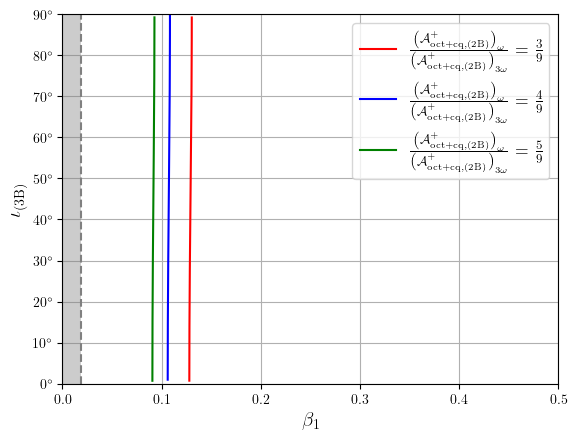

In [32]:
#generate the data
ratios = [3/9, 4/9, 5/9]
b1 = np.linspace(0, 0.5, 500000)

#colors and line styles for plotting
colors = ["Red", "Blue", "Green"]
ratio_labels = [r"$\ \frac{3}{9}$", r"$\ \frac{4}{9}$", r"$\ \frac{5}{9}$"]

for i in range(len(ratios)):
    plt.plot(b1, iota_arccos(b1, b1, ratios[i]), color = colors[i],
             label = r"$\frac{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{\omega}}{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{3\omega}} = $" + ratio_labels[i])

#plot the stability region
plt.axvspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axvline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")

plt.legend(fontsize = 13)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$\iota_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("$%d^{\circ}$"))
plt.ylim(0, 90)
plt.xlim(0, 0.5)

#plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/Iota vs Masses (b1 = b2).pdf", bbox_inches = "tight")
plt.show()

## Case 1: 0.5PN Degeneracy in both Polarization Modes

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.4433756729740707e-12, m1 = 0.002672917912914973, m2 = 0.002672917912914973, m3 = 0.010691671651659894, r = 5.5685789852396175, i = 29.999999999999996, phi = 4.572448166486045

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 694552.5827683469

[1.16923727e-22 3.20269340e-22]
[1.16923727e-22 3.20269340e-22]


(np.float64(0.22707634825985945), np.float64(368.2968459960482))

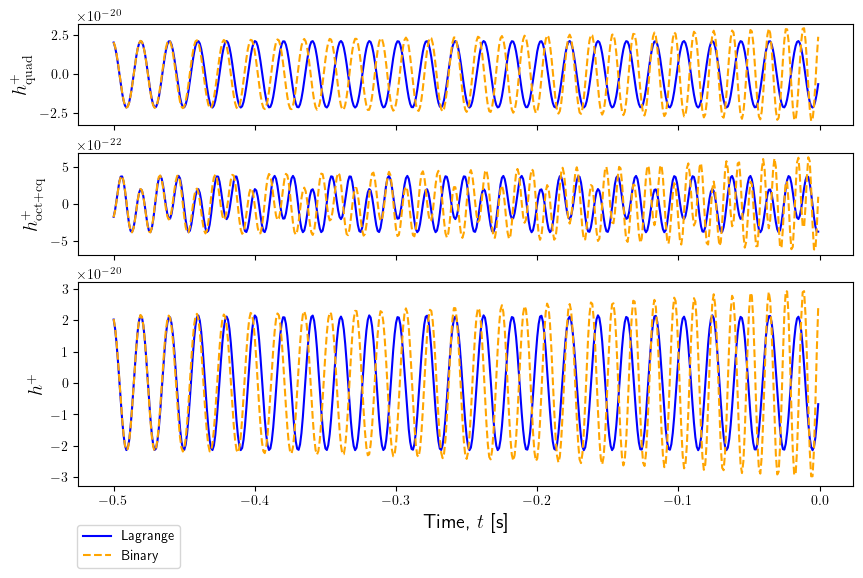

In [34]:
delta_t = 1/1000
t_max = 0.5

params_3B_oct_plus1 = findOctDegeneracy_plus(params_2B, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = True, size = "horizontal",
                             filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN Plus Degeneracy 1 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_plus1).t_c))
print("")
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_plus1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.4433756729740707e-12, m1 = 0.002672917912914973, m2 = 0.002672917912914973, m3 = 0.010691671651659894, r = 5.5685789852396175, i = 29.999999999999996, phi = 4.572448166486045

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 694552.5827683469

[1.16923727e-22 3.20269340e-22]
[1.16923727e-22 3.20269340e-22]


(np.float64(0.22707634825985945), np.float64(368.2968459960482))

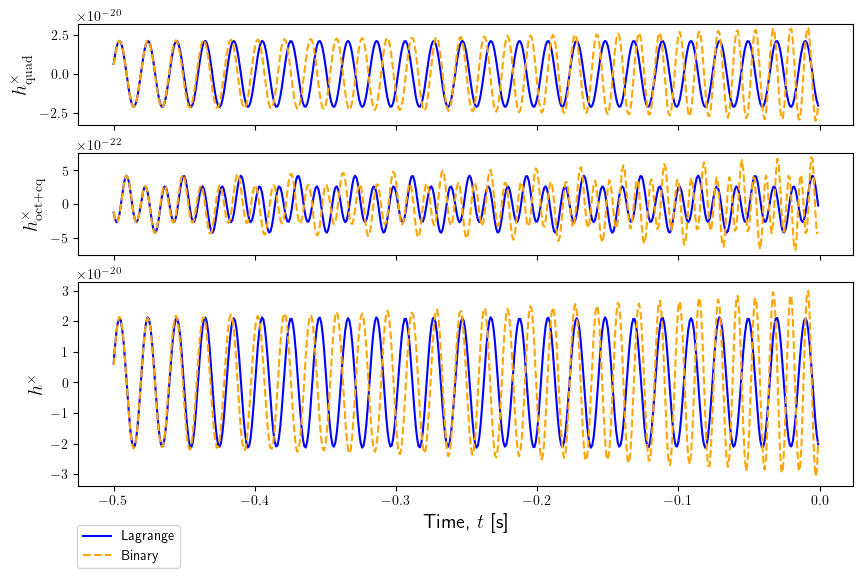

In [35]:
delta_t = 1/1000
t_max = 0.5

params_3B_oct_cross1 = findOctDegeneracy_plus(params_2B, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct_cross1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct_cross1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                             size = "horizontal",
                             filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN Cross Degeneracy 1 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).t_c))
print("")
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Min beta_1 for true degeneracy = 0.16476432952865905
Max beta_1 for true degeneracy = 0.20654241308482615


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Binary Parameters:
l = 1.5e-11, m1 = 30, m2 = 2, r = 2000000.0, i = 15, phi = 0

Lagrange Three-Body Parameters:
l = 1.1366583424670793e-11, m1 = 2.3206774492036395, m2 = 2.3206774492036395, m3 = 9.28270979681456, r = 710707.4688186247, i = 15.000000000000014, phi = 0.7170001251436164

Binary Coalescence: 0.4834588645684629
Lagrange Triple Coalescence: 4.081500919404397

[4.91798131e-22 1.44207820e-21]
[4.91798131e-22 1.44207820e-21]


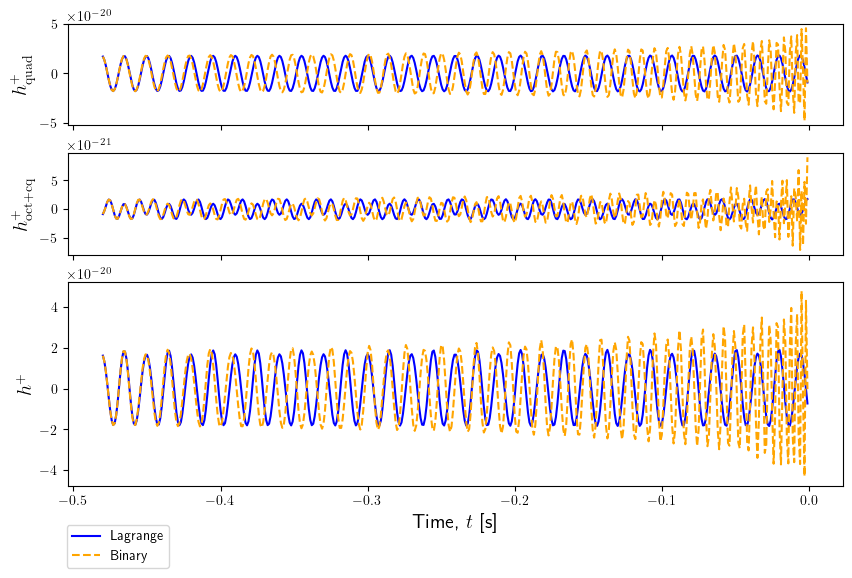

In [36]:
delta_t = 1/1000
t_max = 0.48

params_3B_oct_plus_asymm = findOctDegeneracy_plus(params_2B_asymm, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct_plus_asymm, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B_asymm, params_3B_oct_plus_asymm, t_max = t_max, delta_t = delta_t, radRxn = True,
                             size = "horizontal")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B_asymm).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_plus_asymm).t_c))
print("")
print(waveforms.CircularBinary(*params_2B_asymm).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_plus_asymm).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))

Min beta_1 for true degeneracy = 0.16476432952865905
Max beta_1 for true degeneracy = 0.20654241308482615


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Binary Parameters:
l = 1.5e-11, m1 = 30, m2 = 2, r = 2000000.0, i = 15, phi = 0

Lagrange Three-Body Parameters:
l = 1.1366583424670793e-11, m1 = 2.3206774492036395, m2 = 2.3206774492036395, m3 = 9.28270979681456, r = 710707.4688186247, i = 15.000000000000014, phi = 0.7170001251436164

Binary Coalescence: 0.4834588645684629
Lagrange Triple Coalescence: 4.081500919404397

[4.91798131e-22 1.44207820e-21]
[4.91798131e-22 1.44207820e-21]


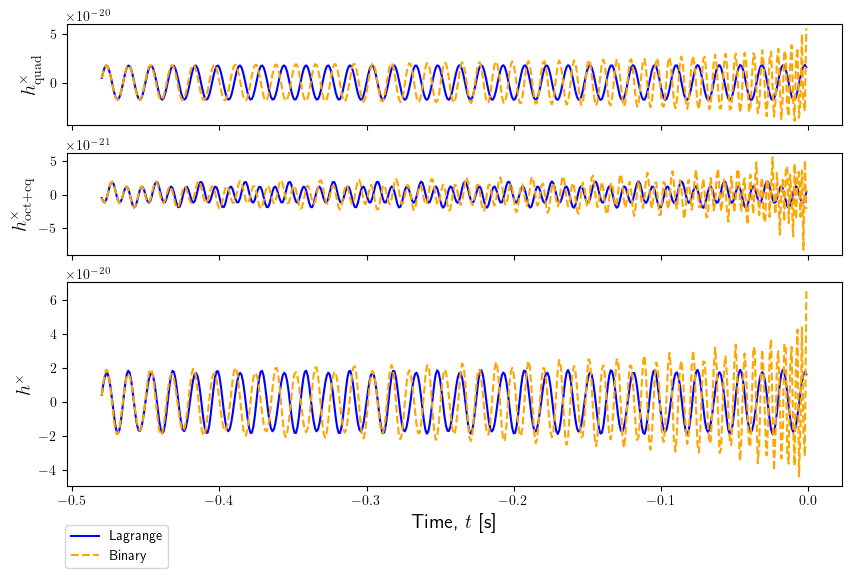

In [37]:
delta_t = 1/1000
t_max = 0.48

params_3B_oct_cross_asymm = findOctDegeneracy_plus(params_2B_asymm, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct_cross_asymm, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B_asymm, params_3B_oct_cross_asymm, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                             size = "horizontal")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B_asymm).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross_asymm).t_c))
print("")
print(waveforms.CircularBinary(*params_2B_asymm).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross_asymm).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus"))

In [38]:
binary_asymm.h_quad(1, ampOnly = True, pol = "cross")

np.float64(1.7702725022683428e-20)

In [39]:
waveforms.CircularLagrangeTriple(*params_3B_oct_cross_asymm).h_quad(1, ampOnly = True, pol = "cross")

np.float64(1.7702725022683383e-20)

## Case 2: 0.5PN Degeneracy in Each Polarization Mode

Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_71795/309211663.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.309373805332004e-11, m1 = 10.452291790150664, m2 = 10.452291790150664, m3 = 44.78271991324934, r = 6655437.262202962, i = 1.917277536430065, phi = 3.1573163405446967

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.644611819425072



(np.float64(nan), np.float64(nan))

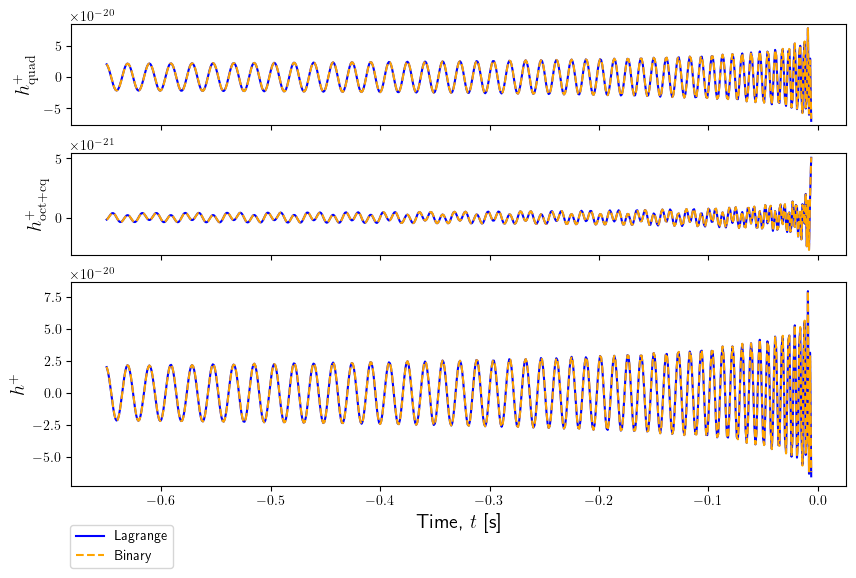

In [41]:
delta_t = 1/1000
t_max = 0.65

params_3B_oct_plus2 = findOctDegeneracy_plus(params_2B, 0.15912194951307287)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct_plus2, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct_plus2, t_max = t_max, delta_t = delta_t, radRxn = True, size = "horizontal",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN Plus Degeneracy 2 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_plus2).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.2038643766661088e-11, m1 = 9.41970424330016, m2 = 9.41970424330016, m3 = 38.249708139461255, r = 5332841.058608916, i = 1.9010546131127184, phi = 5.572474656817931

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.8314669877874763

[1.0566148e-22 3.1698444e-22]
[1.07574789e-22 3.16333786e-22]
[-1.91330921e-24  6.50653909e-25]


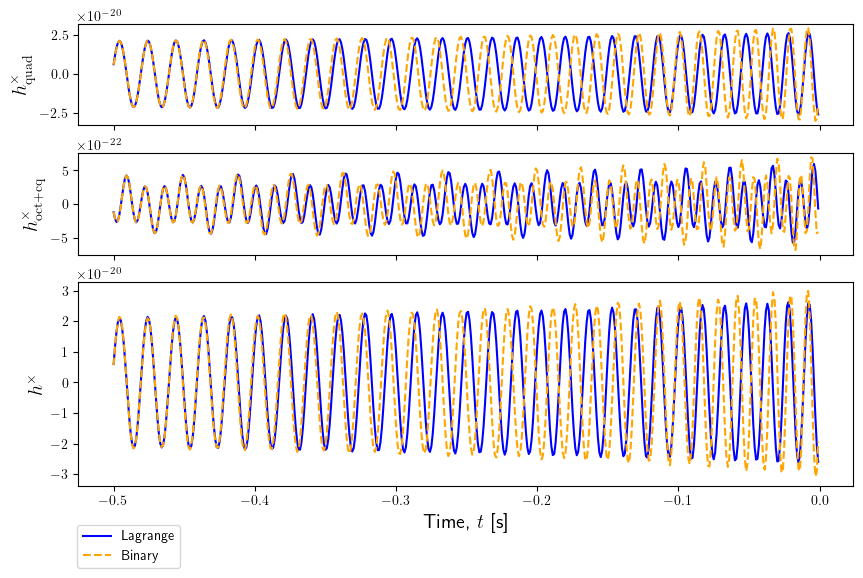

In [42]:
delta_t = 1/1000
t_max = 0.5
params_3B_oct_cross2 = findOctDegeneracy_cross([4e6, 50, 2], *params_2B, beta_1 = 0.165, root_tol = 1e-30, atol = 1e-23)

waveforms.plot_waveform_time(params_2B, params_3B_oct_cross2, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                             size = "horizontal",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN Cross Degeneracy 2 (Horizontal).pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross2).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross2).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct_cross2).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))

## Additional: Cross Degeneracy via PSO

In [40]:
import pyswarms as ps

def octDegeneracy_cross_PSO(x, params_binary, beta_1):
    #r_3B, M_3B, i_3B = x
    a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B = params_binary
    b1 = beta_1
    binary = waveforms.CircularBinary(*params_binary)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    
    eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*x[:, 1]/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(x[:, 2])/x[:, 0]
    eq2 = binary.h_octcq(1, ampOnly = True, pol = "cross")[0] - (np.sqrt(27)/4)*((const.G*x[:, 1]/(const.c**2))**2)*(w_2B/const.c)*b1*(1 - 2*b1)*np.abs(3*b1 - 1)*np.sin(2*x[:, 2])/x[:, 0]
    eq3 = binary.h_octcq(1, ampOnly = True, pol = "cross")[1] - (9*np.sqrt(27)/4)*((const.G*x[:, 1]/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*(1 - 2*b1)*np.sin(2*x[:, 2])/x[:, 0]
    
    return (eq1**2 + eq2**2 + eq3**2)

def findOctDegeneracy_cross_PSO(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, beta_1, pso_options = {'c1': 2, 'c2': 2, 'w': 1}, n_particles = 20, iters = 1000, atol = 1e-23):
    b1 = beta_1
    binary = waveforms.CircularBinary(*[a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B])
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    
    #input initial conditions for root finding must be in pc and solar masses
    #r_3B in [m], M_3B in [kg], and i_3B in [rad]
    options = pso_options
    min_bound = np.array([1e6*pc, (1e-2)*sol, np.radians(0)])
    max_bound = np.array([1e7*pc, 100*sol, np.pi/2])
    bounds = (min_bound, max_bound)
    
    optimizer = ps.single.GlobalBestPSO(n_particles = n_particles, dimensions = 3, options = options, bounds = bounds)
    cost, pos = optimizer.optimize(octDegeneracy_cross_PSO, iters = iters, params_binary = [a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B], beta_1 = b1)
    print("Minimum error found: {}".format(cost))
    
    r_3B, M_3B, i_3B = pos
    b = (const.G*M_3B/(w_2B**2))**(1/3)
    m1_3B = M_3B*beta_1
    m3_3B = M_3B - 2*m1_3B
    i_3B_deg = np.degrees(i_3B)

    delta_t = 1/5000
    t_max = 3
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    
    for phi in shift:
        temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4])
                
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi
    
    return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]

#test case
findOctDegeneracy_cross_PSO(*params_2B, 0.15915, pso_options = {'c1': 4, 'c2': 1, 'w': 0.3}, iters = 5000)

2026-03-05 15:50:16,531 - pyswarms.single.global_best - INFO - Optimize for 5000 iters with {'c1': 4, 'c2': 1, 'w': 0.3}
pyswarms.single.global_best: 100%|████████████████|5000/5000, best_cost=8.79e-47
2026-03-05 15:50:31,280 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 8.792907053496105e-47, best pos: [8.15586810e+22 7.46151273e+31 3.99053713e-02]


Minimum error found: 8.792907053496105e-47


[np.float64(1.916010086964669e-11),
 np.float64(5.970335602854938),
 np.float64(5.970335602854938),
 np.float64(25.573218853070756),
 np.float64(2642860.6938775796),
 np.float64(2.286409356602673),
 np.float64(5.2831588168477)]

2026-03-05 15:50:34,027 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 2, 'c2': 2, 'w': 0.3}
pyswarms.single.global_best: 100%|██████████████|10000/10000, best_cost=4.42e-48
2026-03-05 15:51:03,940 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 4.419843764400544e-48, best pos: [2.85539148e+23 1.58032223e+32 2.96654562e-02]


Minimum error found: 4.419843764400544e-48
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.4605793746769594e-11, m1 = 13.10976207979803, m2 = 13.10976207979803, m3 = 53.23357935433139, r = 9252726.759986175, i = 1.6997054348166458, phi = 0

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.47927242155920907

[1.0566148e-22 3.1698444e-22]
[1.07388437e-22 3.15785800e-22]
[-1.72695706e-24  1.19863993e-24]


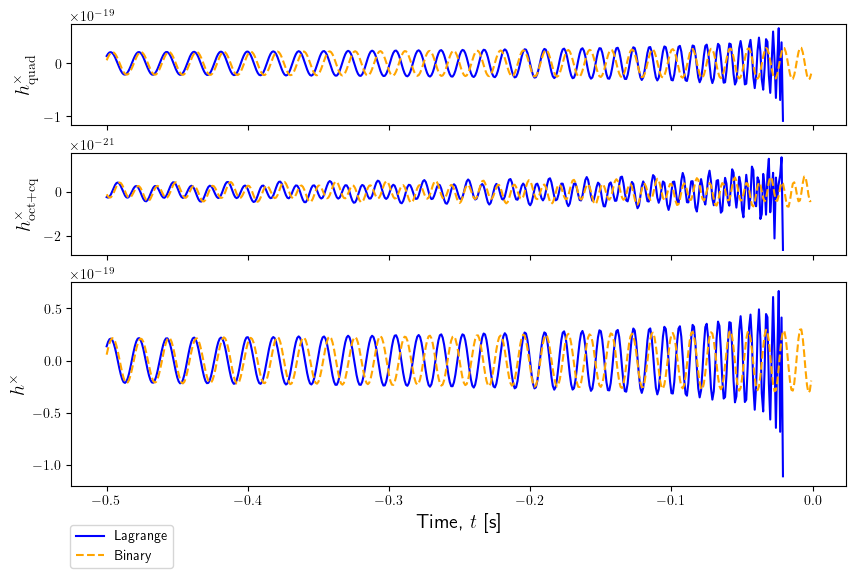

In [41]:
delta_t = 1/1000
t_max = 0.5
params_3B_oct_cross2 = findOctDegeneracy_cross_PSO(*params_2B, beta_1 = 0.165, pso_options = {'c1': 2, 'c2': 2, 'w': 0.3},
                                                   n_particles = 50, iters = 10000, atol = 1e-24)

waveforms.plot_waveform_time(params_2B, params_3B_oct_cross2, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross", size = "horizontal")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross2).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross2).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct_cross2).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))